# Ready and Resilient: starter notebook (practice challenge 04)

**Canada's Defence Tech Hackathon** · Edmonton + online · Nov 14–15, 2026

## 1. The exercise in plain language

This is a **fictional** wildfire evacuation exercise set on **real geography**: the roads, towns, airports and the fuel map are real northern Alberta data, but the fires, the weather, the road closures, the reception-centre capacities, the fleet and everything that happens after the decision time are made up. You play the emergency coordinator at the **decision time**, noon local time on the third day of the scenario. You know what a coordinator would know at that moment: last night's infrared mapping flight, satellite hotspots, daily fire reports, weather observations, fire-weather indices and the latest 72-hour forecast. You don't know where the fires will go next, whether the forecast is right, or which roads will close. Evacuate too late and people are caught by the fire or on a road that closes under them; evacuate too early or too widely and you move thousands of people who never needed to leave, fill up reception centres, and spend trust you will need for the next order.

**The three tasks** (all scored by `score.py` in this folder):

| Task | What you hand in | How it is scored |
|---|---|---|
| **4A threat outlook** | `community_id,p_24h,p_48h,p_72h`: the chance that fire comes within 5 km of each community in the next 24 / 48 / 72 h | mean Brier score (lower is better). Communities already within 5 km at the decision time are not scored |
| **4B evacuation plan** | `orders.csv` (`community_id,order_time,destination_host_id[,share]`) and `trips.csv` (`vehicle_id,depart_time,pickup_community_id,dropoff_host_id`) | penalty points (lower is better): 100 per person exposed (still in a community, or at a reception centre, when the fire reaches it) or trapped (on a road that closes while they drive), 5 per person over a reception centre's capacity, 1 per person moved from a community the fire never came within 15 km of, 25 per failed vehicle trip |
| **4C perimeter nowcast** | GeoJSON polygons with a `fire_id` property: each fire's burned area at the decision time | mean IoU (intersection over union) with the true burned area (higher is better) |

**How to use this notebook.** Run it top to bottom from this folder (it takes well under a minute). Every step only looks at data stamped at or before the decision time, so the same code runs on `scenario_practice` (truth released, so you can score yourself) and on `scenario_eval` (everything after the decision time withheld). Section 7 writes your eval submissions to `submissions/`. All times are UTC; local time is MDT = UTC−6. The baselines are deliberately simple: beat them!

In [1]:
import io, json, math
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import shapely
from shapely.geometry import shape, mapping, Point
from shapely.ops import unary_union, nearest_points, transform as shp_transform
from pyproj import Transformer

import score   # the official scorer (score.py in this folder)

plt.rcParams.update({'figure.dpi': 80, 'savefig.dpi': 80, 'font.size': 9})
pd.set_option('display.width', 160, 'display.max_columns', 30, 'display.precision', 4)

COMMON, SUB = Path('common'), Path('submissions')
SUB.mkdir(exist_ok=True)
TO_M = Transformer.from_crs(4326, 3978, always_xy=True)    # lon/lat -> metres (Canada Atlas Lambert, as the scorer uses)
TO_LL = Transformer.from_crs(3978, 4326, always_xy=True)


def to_m(geom):
    return shp_transform(TO_M.transform, geom)


def to_ll(geom):
    return shp_transform(TO_LL.transform, geom)

## 2. Load the data and see what is known at the decision time

**Common layers** (the same in both scenarios): communities with population, how many people need a ride (`needs_transport`: no car, care homes, hospital patients), road access (`road` or `air_only`) and exit capacity; reception centres (`host_sites.csv`) with capacities; buses at depots and aircraft (`fleet.csv`); aerodromes with their longest runway; the road network as junctions (`road_nodes.csv`) and links with travel times and capacities (`road_edges.csv`, built from the National Road Network); weather stations; and the FBP fuel-type grid (`fuel_types_270m.tif`, optional: reading it needs `rasterio`).

In [2]:
communities = pd.read_csv(COMMON / 'communities.csv', dtype={'road_node_id': str})
hosts = pd.read_csv(COMMON / 'host_sites.csv', dtype={'road_node_id': str})
fleet = pd.read_csv(COMMON / 'fleet.csv')
aerodromes = pd.read_csv(COMMON / 'aerodromes.csv')
stations = pd.read_csv(COMMON / 'weather_stations.csv')
road_nodes = pd.read_csv(COMMON / 'road_nodes.csv').set_index('node_id')
road_edges = pd.read_csv(COMMON / 'road_edges.csv')
road_lines = json.load(open(COMMON / 'road_edges.geojson'))['features']
for df in (communities, stations, road_nodes):
    df['x'], df['y'] = TO_M.transform(df.lon.values, df.lat.values)

fly_in = communities[communities.access == 'air_only']
print(f"{len(communities)} communities, {communities.population.sum():,} people "
      f"({len(fly_in)} fly-in only: {', '.join(fly_in.name)})")
print(f"{len(hosts)} reception centres with {hosts.capacity_people.sum():,} places")
print(f"{len(road_edges):,} road links, {len(aerodromes)} aerodromes, {len(stations)} weather stations")
fleet.groupby(['vehicle_type', 'seats', 'cruise_kmh', 'min_runway_ft', 'needs_paved'], dropna=False).size().rename('count').reset_index()

114 communities, 1,591,638 people (2 fly-in only: Fort Chipewyan, Fox Lake)
26 reception centres with 132,300 places
5,267 road links, 85 aerodromes, 18 weather stations


,vehicle_type,seats,cruise_kmh,min_runway_ft,needs_paved,count
0,bus,48,NaN,NaN,False,117
1,bus,56,NaN,NaN,False,90
2,helicopter_12,12,220.0,0.0,False,2
3,jet_120,120,780.0,6000.0,True,2
4,light_twin_18,18,300.0,2500.0,False,4
5,turboprop_50,50,480.0,4000.0,False,4


**Scenario files** are time-stamped. The practice folder holds all six days so you can score yourself, which also means it is easy to peek at the future by accident. The helper `known()` below keeps only rows stamped at or before the decision time, and `load_scenario()` applies it to every file. On the eval scenario it changes nothing (the files already stop at the decision time), so the same code runs on both.

In [3]:
def known(df, time_col, cutoff):
    # Keep only rows stamped at or before `cutoff`: what a coordinator could know at that moment.
    return df[pd.to_datetime(df[time_col], utc=True) <= cutoff].reset_index(drop=True)


def read_geojson(path):
    feats = json.load(open(path))['features']
    if not feats:
        return pd.DataFrame(columns=['fire_id', 'scan_time', 'geometry'])
    return pd.DataFrame([dict(f['properties'], geometry=shape(f['geometry'])) for f in feats])


TIME_COLUMN = {'fire_reports.csv': 'report_time', 'fire_perimeters_observed.geojson': 'scan_time',
               'satellite_hotspots.csv': 'acq_time', 'weather_observations_hourly.csv': 'timestamp',
               'fwi_daily.csv': 'obs_time', 'weather_forecasts.csv': 'issued',
               'road_closures.csv': 'closed_from', 'aerodrome_closures.csv': 'closed_from'}


def load_scenario(folder):
    folder = Path(folder)
    meta = json.load(open(folder / 'scenario.json'))
    S = dict(name=folder.name, meta=meta, td=pd.Timestamp(meta['decision_time']), visible={})
    for fname, col in TIME_COLUMN.items():
        df = read_geojson(folder / fname) if fname.endswith('.geojson') else pd.read_csv(folder / fname)
        S[fname.split('.')[0]] = known(df, col, S['td'])
        S['visible'][fname] = (len(df), len(S[fname.split('.')[0]]))
    fc = S['weather_forecasts']
    S['weather_forecasts'] = fc[fc.issued == fc.issued.max()].reset_index(drop=True)      # the latest forecast only
    for key in ('road_closures', 'aerodrome_closures'):                                    # a future reopening is not known yet
        df = S[key]
        df['reopened'] = df.reopened.where(pd.to_datetime(df.reopened, utc=True) <= S['td'])
    return S


P = load_scenario('scenario_practice')
td = P['td']
print(f"Decision time: {td:%Y-%m-%d %H:%M} UTC = {td - pd.Timedelta(hours=6):%a %d %b, %H:%M} MDT; "
      f"scenario runs {P['meta']['t0']} to {P['meta']['end_time']}; fires: {', '.join(P['meta']['fires'])}")
pd.DataFrame([(f, n, k) for f, (n, k) in P['visible'].items()], columns=['file', 'rows in file', 'rows known at decision time'])

Decision time: 2030-05-07 06:00 UTC = Tue 07 May, 00:00 MDT; scenario runs 2030-05-04T18:00:00Z to 2030-05-10T18:00:00Z; fires: PRC-001, PRC-002, PRC-003


,file,rows in file,rows known at decision time
0,fire_reports.csv,14,5
1,fire_perimeters_observed.geojson,13,6
2,satellite_hotspots.csv,16749,1956
3,weather_observations_hourly.csv,2610,1098
4,fwi_daily.csv,108,54
5,weather_forecasts.csv,7776,3888
6,road_closures.csv,48,0
7,aerodrome_closures.csv,2,0


The latest situation report and infrared (IR) scan for each fire. The IR flight maps the burned area at about 22:00 local each night, so at noon it is already about 14 hours old, and fires often grow fastest in the afternoon. A fire that started in the evening can show up in the IR scan and the satellite hotspots before it gets a situation report.

In [4]:
display(P['fire_reports'].sort_values('report_time').groupby('fire_id').tail(1))
P['fire_perimeters_observed'].drop(columns='geometry')

,fire_id,report_time,first_detected,origin_lat,origin_lon,estimated_size_ha,status,cause
1,PRC-001,2030-05-06T23:00:00Z,2030-05-05T00:14:10Z,55.1828,-114.9177,8840,Out of control,Under investigation
3,PRC-002,2030-05-06T23:00:00Z,2030-05-05T17:17:26Z,56.6454,-111.5587,1800,Out of control,Under investigation
4,PRC-003,2030-05-06T23:00:00Z,2030-05-06T01:40:36Z,56.3030,-114.9960,7580,Out of control,Under investigation


,fire_id,scan_time,mapped_area_ha,source
0,PRC-001,2030-05-05T04:00:00Z,590,airborne IR scan (synthetic)
1,PRC-001,2030-05-06T04:00:00Z,3560,airborne IR scan (synthetic)
2,PRC-002,2030-05-06T04:00:00Z,460,airborne IR scan (synthetic)
3,PRC-003,2030-05-06T04:00:00Z,490,airborne IR scan (synthetic)
4,PRC-001,2030-05-07T04:00:00Z,13840,airborne IR scan (synthetic)
5,PRC-002,2030-05-07T04:00:00Z,2550,airborne IR scan (synthetic)


**Fire weather.** `fwi_daily.csv` holds the Canadian Fire Weather Index System codes, computed from the 13:00 local observation (so at noon you have yesterday's values). The ones used below: **FFMC**, how dry the fine surface fuels are (above about 90 means very easy ignition), and **ISI** (Initial Spread Index), which combines FFMC with wind speed into a measure of how fast a fire can spread. The plot shows the latest 72 h forecast at the stations nearest each fire. Watch for a sudden change in wind direction: a cold front can turn a fire's long flank into a new head fire.

Latest FWI values (yesterday 13:00 local) at the station nearest each fire:


,obs_time,ffmc,dmc,dc,isi,bui,fwi,fire
station_id,,,,,,,,
WX-CYZH,2030-05-06T19:00:00Z,95.5,43.7,209.3,19.8,57.4,37.9,PRC-001
WX-CYMM,2030-05-06T19:00:00Z,94.2,41.7,208.6,20.3,55.6,37.9,PRC-002
WX-CEH5,2030-05-06T19:00:00Z,95.9,44.2,209.8,24.2,57.9,43.3,PRC-003


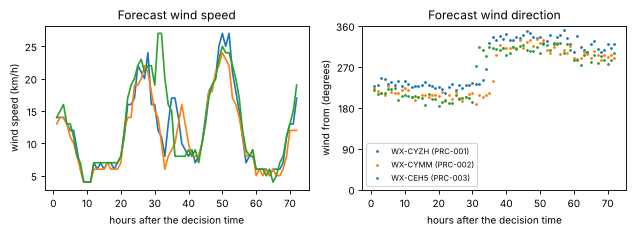

In [5]:
def fire_locations(S):
    # lon/lat of each known fire: the latest IR perimeter's centre, else the reported origin
    loc = {r.fire_id: (r.origin_lon, r.origin_lat) for r in S['fire_reports'].itertuples()}
    loc.update({r.fire_id: (r.geometry.centroid.x, r.geometry.centroid.y) for r in S['fire_perimeters_observed'].itertuples()})
    return loc


def nearest_station(lon, lat):
    return stations.station_id[int(np.argmin(np.hypot((stations.lon - lon) * math.cos(math.radians(lat)), stations.lat - lat)))]


near = {fid: nearest_station(*ll) for fid, ll in sorted(fire_locations(P).items())}
print('Latest FWI values (yesterday 13:00 local) at the station nearest each fire:')
display(P['fwi_daily'].sort_values('obs_time').groupby('station_id').tail(1).set_index('station_id')
        .reindex(list(near.values()))[['obs_time', 'ffmc', 'dmc', 'dc', 'isi', 'bui', 'fwi']].assign(fire=list(near)))

fc = P['weather_forecasts']
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
for fid, st in near.items():
    f = fc[fc.station_id == st]
    ax[0].plot(f.lead_h, f.wind_speed_kmh, label=f'{st} ({fid})')
    ax[1].plot(f.lead_h, f.wind_dir_deg, '.', ms=3, label=f'{st} ({fid})')
ax[0].set(xlabel='hours after the decision time', ylabel='wind speed (km/h)', title='Forecast wind speed')
ax[1].set(xlabel='hours after the decision time', ylabel='wind from (degrees)', title='Forecast wind direction', yticks=[0, 90, 180, 270, 360])
ax[1].legend(fontsize=7)
plt.tight_layout()

## 3. The map at the decision time

Roads, communities (sized by population), the last IR perimeters, satellite hotspots from the last 24 h, and the forecast wind for the next 24 h at stations near the fires (arrows point the way the wind blows, i.e. where a fire would be pushed).

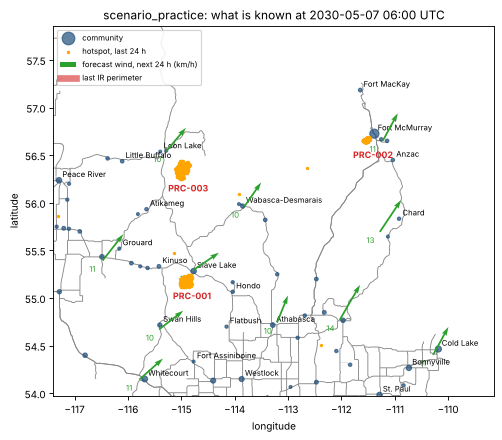

In [6]:
MAJOR = {'Freeway', 'Expressway / Highway', 'Arterial'}
road_segs = [np.asarray(f['geometry']['coordinates']) for f in road_lines]
road_major = np.array([f['properties']['road_class'] in MAJOR for f in road_lines])


def fill_polys(ax, geom, **kw):
    for g in getattr(geom, 'geoms', [geom]):
        ax.fill(*g.exterior.xy, **kw)


def draw_map(S, perims=None, ax=None, margin=1.2):
    ax = ax or plt.subplots(figsize=(8, 6))[1]
    fires = fire_locations(S)
    lon, lat = zip(*fires.values())
    x0, x1, y0, y1 = min(lon) - 2 * margin, max(lon) + 2 * margin, min(lat) - margin, max(lat) + margin
    ax.add_collection(LineCollection([s for s, m in zip(road_segs, road_major) if not m], colors='#cccccc', linewidths=0.4))
    ax.add_collection(LineCollection([s for s, m in zip(road_segs, road_major) if m], colors='#888888', linewidths=0.8))
    ax.scatter(communities.lon, communities.lat, s=4 + np.sqrt(communities.population) / 4, c='#1f4e79', alpha=0.7, zorder=3, label='community')
    # label the bigger towns and the ones near a fire, skipping any within ~35 km of a label already placed
    fx, fy = TO_M.transform(np.array(lon), np.array(lat))
    near_fire = np.hypot(communities.x.values[:, None] - fx, communities.y.values[:, None] - fy).min(axis=1) < 100e3
    inside = communities.lon.between(x0, x1) & communities.lat.between(y0, y1)
    cand = communities[inside & ((communities.population >= 2500) | near_fire | (communities.access == 'air_only'))]
    placed = []
    for c in cand.assign(nf=near_fire[cand.index]).sort_values(['nf', 'population'], ascending=False).itertuples():
        if all(math.hypot(c.x - px, c.y - py) > 35e3 for px, py in placed):
            ax.annotate(c.name, (c.lon, c.lat), fontsize=7, xytext=(3, 3), textcoords='offset points', zorder=4)
            placed.append((c.x, c.y))
    for r in S['fire_perimeters_observed'].sort_values('scan_time').groupby('fire_id').tail(1).itertuples():
        fill_polys(ax, r.geometry, color='#d62728', alpha=0.6, zorder=5)
    if perims:
        for g in perims.values():
            for gg in getattr(to_ll(g), 'geoms', [to_ll(g)]):
                ax.plot(*gg.exterior.xy, color='black', lw=0.8, zorder=6)
    for fid, (flon, flat) in fires.items():
        ax.annotate(fid, (flon, flat), color='#d62728', fontsize=8, fontweight='bold', xytext=(-12, -16), textcoords='offset points', zorder=7)
    hs = S['satellite_hotspots']
    hs = hs[(hs['type'] == 0) & (pd.to_datetime(hs.acq_time, utc=True) > S['td'] - pd.Timedelta(hours=24))]
    ax.scatter(hs.longitude, hs.latitude, s=4, c='orange', zorder=6, label='hotspot, last 24 h')
    # forecast wind for the next 24 h, as an average wind vector
    fc = S['weather_forecasts']
    fc = fc[pd.to_datetime(fc.valid, utc=True) <= S['td'] + pd.Timedelta(hours=24)]
    to_rad = np.radians((fc.wind_dir_deg + 180) % 360)
    w = fc.assign(u=fc.wind_speed_kmh * np.sin(to_rad), v=fc.wind_speed_kmh * np.cos(to_rad)).groupby('station_id')[['u', 'v']].mean()
    w = w.join(stations.set_index('station_id')[['lon', 'lat']])
    w = w[w.lon.between(x0, x1) & w.lat.between(y0, y1)]
    ax.quiver(w.lon, w.lat, w.u, w.v, color='#2ca02c', scale=150, width=0.004, zorder=8, label='forecast wind, next 24 h (km/h)')
    for s in w.itertuples():
        ax.annotate(f'{math.hypot(s.u, s.v):.0f}', (s.lon, s.lat), color='#2ca02c', fontsize=7, xytext=(-12, -10), textcoords='offset points')
    ax.plot([], [], color='#d62728', lw=6, alpha=0.6, label='last IR perimeter')
    if perims:
        ax.plot([], [], color='black', lw=0.8, label='nowcast perimeter')
    ax.set(xlim=(x0, x1), ylim=(y0, y1), aspect=1 / math.cos(math.radians((y0 + y1) / 2)), xlabel='longitude', ylabel='latitude')
    ax.set_title(f"{S['name']}: what is known at {S['td']:%Y-%m-%d %H:%M} UTC")
    ax.legend(loc='best', fontsize=7, framealpha=0.85)
    return ax


draw_map(P);

## 4. Baseline 4C: perimeter nowcast

The last IR scan is about 14 hours old. The freshest observations are the satellite hotspots: VIIRS (375 m pixels) passes over in the early hours of the morning. The baseline takes, for each fire:

* the latest IR perimeter, **plus**
* a 400 m circle around every VIIRS hotspot from the last 18 h with `type == 0` (vegetation fire; `type == 2` marks static industrial heat sources such as oil sands plants),

where each hotspot is assigned to the nearest known fire (distance to its IR perimeter, or to the reported origin if there is no scan yet), and hotspots more than 25 km from any fire are dropped as false detections. A fire with neither an IR scan nor hotspots gets a circle with its reported size.

In [7]:
def known_fires(S):
    # Each fire we know about: its latest IR perimeter (metres) and its reported origin and size.
    fires = {}
    for r in S['fire_perimeters_observed'].sort_values('scan_time').itertuples():
        fires.setdefault(r.fire_id, {}).update(ir=to_m(r.geometry).buffer(0), ir_time=r.scan_time)
    for r in S['fire_reports'].sort_values('report_time').itertuples():
        fires.setdefault(r.fire_id, {}).update(origin=Point(TO_M.transform(r.origin_lon, r.origin_lat)), size_ha=r.estimated_size_ha)
    for f in fires.values():
        f.setdefault('ir', None)
        f.setdefault('origin', f['ir'].centroid if f['ir'] is not None else None)
        f.setdefault('size_ha', f['ir'].area / 1e4 if f['ir'] is not None else 100)
    return fires


def nowcast_perimeters(S, hours_back=18, buffer_m=400, max_km=25):
    fires = known_fires(S)
    ids = list(fires)
    anchors = [fires[f]['ir'] if fires[f]['ir'] is not None else fires[f]['origin'] for f in ids]
    hs = S['satellite_hotspots']
    recent = pd.to_datetime(hs.acq_time, utc=True) > S['td'] - pd.Timedelta(hours=hours_back)
    hs = hs[recent & (hs.instrument == 'VIIRS') & (hs['type'] == 0)]
    pts = shapely.points(np.c_[TO_M.transform(hs.longitude.values, hs.latitude.values)])
    dist = np.stack([shapely.distance(pts, a) for a in anchors], axis=1) if len(pts) else np.zeros((0, len(ids)))
    owner = np.where(dist.min(axis=1) < max_km * 1000, dist.argmin(axis=1), -1) if len(pts) else np.array([], int)
    perims = {}
    for k, fid in enumerate(ids):
        parts = [fires[fid]['ir']] if fires[fid]['ir'] is not None else []
        parts += list(shapely.buffer(pts[owner == k], buffer_m))
        if not parts:
            parts = [fires[fid]['origin'].buffer(math.sqrt(fires[fid]['size_ha'] * 1e4 / math.pi))]
        perims[fid] = unary_union(parts)
    return perims


def round_coords(c, nd=5):
    return [round_coords(v, nd) for v in c] if isinstance(c[0], (list, tuple)) else [round(c[0], nd), round(c[1], nd)]


def write_perimeters(perims, path):
    feats = []
    for fid, g in perims.items():
        gj = mapping(to_ll(g))
        gj['coordinates'] = round_coords(gj['coordinates'])
        feats.append(dict(type='Feature', properties=dict(fire_id=fid), geometry=gj))
    json.dump(dict(type='FeatureCollection', features=feats), open(path, 'w'))


perims_p = nowcast_perimeters(P)
write_perimeters(perims_p, SUB / 'practice_perimeters.geojson')
Wp = score.World('scenario_practice')            # loads the practice truth (only possible for practice)
iou = score.score_perimeter(Wp, SUB / 'practice_perimeters.geojson', quiet=True)
last_ir = {f: v['ir'] for f, v in known_fires(P).items()}
pd.DataFrame({'last IR scan (ha)': {f: (g.area / 1e4 if g is not None else 0) for f, g in last_ir.items()},
              'nowcast (ha)': {f: g.area / 1e4 for f, g in perims_p.items()},
              'IoU': iou}).round(3)

,last IR scan (ha),nowcast (ha),IoU
PRC-001,13551.935,13554.944,0.850
PRC-002,2617.227,2750.564,0.831
PRC-003,422.811,5092.901,0.258
score_mean_iou,NaN,NaN,0.647


On practice you can look at the truth. Grey is the true burned area at the decision time, red the last IR scan, black the nowcast. Most of the miss is growth during the morning, after the last satellite pass.

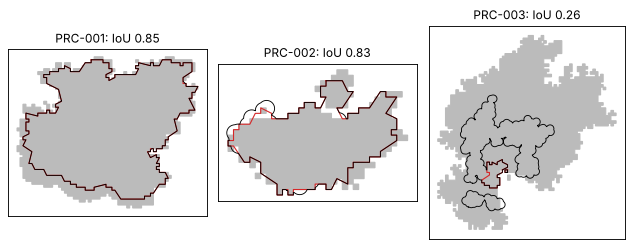

In [8]:
truth_p = read_geojson('scenario_practice/truth/fire_perimeters_truth_3h.geojson')
truth_p = truth_p[truth_p.hours_since_t0 == P['meta']['decision_hours_since_t0']].set_index('fire_id')
fig, axs = plt.subplots(1, len(perims_p), figsize=(8, 3))
for ax, (fid, g) in zip(axs, perims_p.items()):
    if fid in truth_p.index:
        fill_polys(ax, to_m(truth_p.geometry[fid]), color='#bbbbbb')
    if last_ir.get(fid) is not None:
        for gg in getattr(last_ir[fid], 'geoms', [last_ir[fid]]):
            ax.plot(*gg.exterior.xy, color='#d62728', lw=1)
    for gg in getattr(g, 'geoms', [g]):
        ax.plot(*gg.exterior.xy, color='black', lw=0.8)
    ax.set(aspect=1, xticks=[], yticks=[], title=f"{fid}: IoU {iou.get(fid, 0):.2f}")
plt.tight_layout()

## 5. Baseline 4A: threat outlook

A simple, explainable heuristic. For each fire and each community:

1. **Distance** from the community to the fire's current edge (the nowcast above).
2. **How fast could the fire's head move**, hour by hour over the next 72 h, from the latest forecast at the weather station nearest the fire: we compute the forecast **ISI** from yesterday's FFMC and the forecast wind, and turn it into a speed of about 0.035 km/h per ISI point. Humid hours (nights, rain) barely burn, so the speed is scaled down when relative humidity is high.
3. **How much of that speed points at the community.** The head of a fire runs downwind; the flanks and the back creep at about a quarter of that speed. We compare the downwind direction each hour with the compass bearing from the fire edge to the community.
4. **Reach** = the sum over the hours: how far the fire could plausibly travel toward the community within 24, 48 and 72 h.
5. **Probability** = a logistic curve of (reach − (distance − 5 km)): above 50% when the fire could cover the gap to the 5 km line. The curve is wider for longer reaches, because longer forecasts are less certain.

Several fires combine as `1 − Π(1 − p_fire)`. The constants were picked by eye and lightly checked on the practice fires (which advanced about 5 km a day toward the towns at risk), so treat them as a starting point.

*Pitfall:* compute compass bearings from lon/lat, not from projected x/y. In EPSG:3978 "grid north" is 15–20° off true north in this region, and wind directions are relative to true north.

In [9]:
def isi(ffmc, wind_kmh):
    # Initial Spread Index of the Canadian FWI System (Van Wagner 1987): fine-fuel dryness x wind.
    m = 147.2 * (101 - ffmc) / (59.5 + ffmc)
    return 0.208 * np.exp(0.05039 * wind_kmh) * 91.9 * np.exp(-0.1386 * m) * (1 + m ** 5.31 / 4.93e7)


def bearing(lon1, lat1, lon2, lat2):
    # Compass bearing (radians from true north) from point 1 to point 2; fine over short distances.
    return math.atan2((lon2 - lon1) * math.cos(math.radians((lat1 + lat2) / 2)), lat2 - lat1)


KM_PER_ISI = 0.035      # head-fire speed (km/h) per ISI point
SIDE = 0.25             # flanks and back spread at about this fraction of the head speed
HORIZONS = (24, 48, 72)


def threat_outlook(S, perims):
    fc = S['weather_forecasts'].copy()
    fc['h'] = (pd.to_datetime(fc.valid, utc=True) - S['td']).dt.total_seconds() / 3600
    fc = fc[(fc.h > 0) & (fc.h <= 72)].sort_values('h')
    ffmc_now = S['fwi_daily'].sort_values('obs_time').groupby('station_id').ffmc.last()
    p = np.zeros((len(communities), len(HORIZONS)))
    dist = np.full(len(communities), np.inf)
    which = np.array([''] * len(communities), dtype=object)
    for fid, poly in perims.items():
        c0 = poly.centroid
        st = stations.station_id[int(np.argmin(np.hypot(stations.x - c0.x, stations.y - c0.y)))]
        f = fc[fc.station_id == st]
        dryness = np.clip((65 - f.rh_pct.values) / 45, 0, 1)
        speed = KM_PER_ISI * isi(ffmc_now.get(st, ffmc_now.median()), f.wind_speed_kmh.values) * dryness
        downwind = np.radians((f.wind_dir_deg.values + 180) % 360)     # wind_dir_deg is where the wind comes FROM
        for i, c in enumerate(communities.itertuples()):
            here = Point(c.x, c.y)
            d = poly.distance(here) / 1000
            if d < dist[i]:
                dist[i], which[i] = d, fid
            if d <= 5:
                p[i] = 1.0
                continue
            elon, elat = TO_LL.transform(*nearest_points(poly, here)[0].coords[0])
            toward = SIDE + (1 - SIDE) * np.clip(np.cos(downwind - bearing(elon, elat, c.lon, c.lat)), 0, None)
            reach = np.cumsum(speed * toward)
            for j, L in enumerate(HORIZONS):
                r = reach[f.h.values <= L][-1] if (f.h.values <= L).any() else 0.0
                pf = 1 / (1 + math.exp(-(r - (d - 5)) / (2 + 0.3 * r)))
                p[i, j] = 1 - (1 - p[i, j]) * (1 - pf)
    p = np.maximum.accumulate(p, axis=1)                                # a longer window can't be less likely
    out = pd.DataFrame(p.round(4), columns=[f'p_{L}h' for L in HORIZONS])
    out.insert(0, 'community_id', communities.community_id)
    out['km_to_fire'], out['nearest_fire'] = dist.round(1), which
    return out


risk_p = threat_outlook(P, perims_p)
risk_p[['community_id', 'p_24h', 'p_48h', 'p_72h']].to_csv(SUB / 'practice_forecast.csv', index=False)
brier = score.score_forecast(Wp, SUB / 'practice_forecast.csv', quiet=True)
zeros = risk_p[['community_id']].assign(p_24h=0.0, p_48h=0.0, p_72h=0.0)
brier0 = score.score_forecast(Wp, io.StringIO(zeros.to_csv(index=False)), quiet=True)      # 'it will never happen', for contrast
pd.DataFrame([brier0, brier], index=['always 0', 'baseline'])[['brier_24h', 'brier_48h', 'brier_72h', 'score_mean_brier', 'positives_24h', 'positives_48h', 'positives_72h']].round(4)

,brier_24h,brier_48h,brier_72h,score_mean_brier,positives_24h,positives_48h,positives_72h
always 0,0.0000,0.000,0.0089,0.0030,0,0,1
baseline,0.0014,0.005,0.0028,0.0031,0,0,1


Top-risk communities. On practice we can add the true answer: how many hours after the decision time the fire really came within 5 km (blank = never within the 6 days).

In [10]:
truth_ct = pd.read_csv('scenario_practice/truth/community_fire_times.csv')       # practice truth, for checking only
top = risk_p.merge(communities[['community_id', 'name', 'population']]).merge(truth_ct[['community_id', 't_within_5km_h']])
top['truth: within 5 km after (h)'] = (top.t_within_5km_h - P['meta']['decision_hours_since_t0']).round(1)
top.sort_values('p_72h', ascending=False).head(10)[['name', 'population', 'nearest_fire', 'km_to_fire', 'p_24h', 'p_48h', 'p_72h', 'truth: within 5 km after (h)']]

,name,population,nearest_fire,km_to_fire,p_24h,p_48h,p_72h,truth: within 5 km after (h)
17,Slave Lake,6836,PRC-001,5.1,0.8963,0.9090,0.9099,-9.5
3,Fort McMurray,66573,PRC-002,7.2,0.8154,0.8466,0.8467,-10.2
79,Draper,500,PRC-002,12.9,0.3620,0.6262,0.6268,53.3
74,Saprae Creek,572,PRC-002,19.5,0.0671,0.3005,0.3013,NaN
111,Red Earth,160,PRC-003,23.3,0.1308,0.2587,0.2655,NaN
110,Loon Lake,170,PRC-003,27.4,0.0301,0.0937,0.0980,NaN
99,Smith,300,PRC-001,47.7,0.0015,0.0259,0.0317,NaN
83,Hondo,460,PRC-001,48.8,0.0009,0.0222,0.0276,NaN
78,Anzac,506,PRC-002,34.7,0.0001,0.0110,0.0111,NaN
56,Kinuso,880,PRC-001,28.8,0.0011,0.0092,0.0106,NaN


## 6. Baseline 4B: rule-based evacuation plan

The rules, in the order a coordinator might apply them:

1. **Who leaves:** order every community with `p_72h ≥ 0.2`, 30 minutes after the decision time (time to get the word out). The penalties are lopsided (100 points per person exposed vs 1 per person moved for nothing), so the bar is deliberately low.
2. **Where to:** only reception centres outside the risk area (their own `p_72h < 0.05` and more than 30 km from any fire). In the scorer, people delivered to a reception centre in a town the fire reaches count as exposed.
3. **Route sanity check** with `networkx` on `road_edges.csv` (minus the roads already closed): drivers in the scorer take the fastest open road, so we only use a reception centre if that fastest route does not bring people closer to a fire than they already are (allowing 2 km to get out of town). Routes that pass a fire risk closing while people are on them.
4. **Drivers** (`population − needs_transport`) fill the nearest safe reception centres by road time; when one is too small, the order is split with `share`.
5. **People without a ride** (`needs_transport`) go by bus to one reception centre. We add buses from the nearest depots (only ones whose route in is also clear) until our estimated timetable picks up the last person within 8 hours of the order.
6. **Fly-in communities** at risk (`access == air_only`: everyone needs a seat) get aircraft shuttles under the same 8-hour rule. The aerodromes nearest the community and nearest the reception centre (within 40 km) must both have a long enough runway, as in the scorer; helicopters fly town to town.

`depart_time` in `trips.csv` is the earliest time a vehicle may leave; the scorer runs each vehicle's trips in time order and starts each one when the vehicle is back from the previous one. We still estimate a realistic timetable so you can read it.

In [11]:
ORDER_P72, HOST_MAX_P72, HOST_MIN_KM = 0.20, 0.05, 30
ORDER_DELAY_H, TARGET_H, BUS_MAX_H = 0.5, 8, 8     # last pickup within ~8 h of the order; buses from depots up to 8 h away
SLOW, BOARD_H, UNLOAD_H, AIR_OVERHEAD_H, AIR_GROUND_H = 1.1, 20 / 60, 15 / 60, 0.4, 0.5     # same constants as score.py


def road_graph(closed_edge_ids=()):
    G = nx.Graph()
    for e in road_edges.itertuples():
        if G.has_edge(e.u, e.v) and G[e.u][e.v]['hours'] <= e.travel_time_min / 60:
            continue                                                       # keep the faster of two parallel links, like the scorer
        G.add_edge(e.u, e.v, hours=e.travel_time_min / 60, edge_id=e.edge_id)
    closed = set(closed_edge_ids)
    G.remove_edges_from([(u, v) for u, v, d in G.edges(data=True) if d['edge_id'] in closed])
    return G


def route_is_clear(path, fire_m):
    d = shapely.distance(shapely.points(road_nodes.loc[path, ['x', 'y']].values), fire_m) / 1000
    return d.min() >= min(d[0], d[-1], 10) - 2, d.min()


def km(lat1, lon1, lat2, lon2):
    p1, p2 = np.radians(lat1), np.radians(lat2)
    a = np.sin((p2 - p1) / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(np.radians(lon2 - lon1) / 2) ** 2
    return 2 * 6371.0088 * np.arcsin(np.sqrt(a))


def runway_near(lat, lon, v, closed, max_km=40):
    # The aerodrome the scorer will use for this aircraft (nearest long-enough runway within 40 km), or None.
    if v.vehicle_type == 'helicopter_12':
        return 'heli'
    ok = (aerodromes.longest_runway_ft >= v.min_runway_ft) & (aerodromes.paved.astype(bool) | (not bool(v.needs_paved)))
    a = aerodromes[ok]
    d = km(lat, lon, a.lat.values, a.lon.values)
    if not len(d) or d.min() > max_km or a.aerodrome_id.values[d.argmin()] in closed:
        return None
    return a.aerodrome_id.values[d.argmin()]


def shuttle(vehicles, riders):
    # Shuttle timetable: each load goes on whichever vehicle can reach the pickup first. Times in hours after the order.
    # vehicles: dicts with vid, seats, first_h (to the pickup the first time), load_h, there_h (pickup -> host), back_h (host -> pickup)
    free_at, started, out, left, last = {v['vid']: 0.0 for v in vehicles}, set(), [], riders, 0.0
    while left > 0 and vehicles:
        arrive = {v['vid']: free_at[v['vid']] + (v['back_h'] if v['vid'] in started else v['first_h']) for v in vehicles}
        v = min(vehicles, key=lambda v: (arrive[v['vid']], -v['seats']))
        out.append((v['vid'], free_at[v['vid']]))
        last = max(last, arrive[v['vid']])
        free_at[v['vid']] = arrive[v['vid']] + v['load_h'] + v['there_h'] + UNLOAD_H
        started.add(v['vid']); left -= v['seats']
    return out, last, max(left, 0)


def enough_vehicles(cands, riders):
    # Add vehicles, soonest first, until the last pickup is within TARGET_H (or we run out of vehicles).
    use = []
    for v in sorted(cands, key=lambda v: v['first_h']):
        use.append(v)
        out, last, left = shuttle(use, riders)
        if left == 0 and last <= TARGET_H:
            break
    return shuttle(use, riders)

In [12]:
def make_plan(S, perims, risk):
    t_order = S['td'] + pd.Timedelta(hours=ORDER_DELAY_H)
    iso = lambda h: (t_order + pd.Timedelta(hours=h)).strftime('%Y-%m-%dT%H:%M:%SZ')
    rc = S['road_closures']
    G = road_graph(rc.edge_id[rc.reopened.isna()])
    fire_m = unary_union(list(perims.values()))
    R = communities.merge(risk, on='community_id')
    H = hosts.merge(R[['community_id', 'p_72h', 'km_to_fire']], on='community_id')
    H['safe'] = (H.p_72h < HOST_MAX_P72) & (H.km_to_fire > HOST_MIN_KM)
    spare = H.set_index('host_id').capacity_people.astype(float).to_dict()
    buses = fleet[fleet.vehicle_type == 'bus'].merge(communities[['community_id', 'road_node_id']], left_on='base_community_id', right_on='community_id')
    free = set(fleet.vehicle_id)
    orders, trips, log = [], [], []
    todo = R[R.p_72h >= ORDER_P72].sort_values('p_24h', ascending=False)

    for c in todo[todo.access == 'road'].itertuples():
        hours, paths = nx.single_source_dijkstra(G, c.road_node_id, weight='hours')
        good = []                                                          # safe hosts with a clear route, nearest first
        for h in H[H.safe].itertuples():
            if h.road_node_id in hours and route_is_clear(paths[h.road_node_id], fire_m)[0]:
                good.append((hours[h.road_node_id], h.host_id))
        good.sort()
        if not good:
            log.append(dict(community=c.name, note='no safe reception centre reachable by road')); continue
        drivers, riders = c.population - c.needs_transport, c.needs_transport
        ride_host = next((h for _, h in good if spare[h] >= riders), good[0][1])
        spare[ride_host] -= riders
        left, split = drivers, []
        for _, h in good:
            n = min(left, max(spare[h] - 1, 0))
            if n >= 1:
                split.append((h, n)); spare[h] -= n; left -= n
            if left <= 0:
                break
        if left > 0:                                                      # nowhere left: overflow beats exposure
            split.append((good[0][1], left)); spare[good[0][1]] -= left
        for h, n in split:
            if drivers > 0:
                orders.append(dict(community_id=c.community_id, order_time=iso(0), destination_host_id=h, share=round(n / drivers, 8)))
        # buses: nearest depots first, only along clear routes
        to_host = hours[H.set_index('host_id').road_node_id[ride_host]]
        cands = []
        for b in buses[buses.vehicle_id.isin(free)].itertuples():
            t = hours.get(b.road_node_id, np.inf)
            if t <= BUS_MAX_H and route_is_clear(paths[b.road_node_id], fire_m)[0]:
                cands.append(dict(vid=b.vehicle_id, seats=b.seats, first_h=t * SLOW, load_h=BOARD_H, there_h=to_host * SLOW, back_h=to_host * SLOW))
        sched, last_pickup, left = enough_vehicles(cands, riders)
        for vid, h0 in sched:
            trips.append(dict(vehicle_id=vid, depart_time=iso(h0), pickup_community_id=c.community_id, dropoff_host_id=ride_host))
        free -= {vid for vid, _ in sched}
        log.append(dict(community=c.name, p_24h=c.p_24h, p_72h=c.p_72h, people=c.population,
                        drivers_to=', '.join(f'{h} ({n:.0f})' for h, n in split), riders=riders, riders_to=ride_host,
                        vehicles=len({vid for vid, _ in sched}), trips=len(sched), last_pickup_h=round(last_pickup, 1),
                        note='' if left == 0 else f'{left} people without a seat'))

    ac = S['aerodrome_closures']
    closed_ad = set(ac.aerodrome_id[ac.reopened.isna()])
    ad = aerodromes.set_index('aerodrome_id')
    for c in todo[todo.access == 'air_only'].itertuples():
        riders, plan = c.population, None
        cands = H[H.safe].assign(dist=lambda d: km(c.lat, c.lon, d.lat.values, d.lon.values)).sort_values('dist')
        for h in cands[[spare[x] >= riders for x in cands.host_id]].itertuples():
            planes = []
            for v in fleet[(fleet.vehicle_type != 'bus') & fleet.vehicle_id.isin(free)].itertuples():
                pa, da = runway_near(c.lat, c.lon, v, closed_ad), runway_near(h.lat, h.lon, v, closed_ad)
                if pa is None or da is None:
                    continue
                pick = (c.lat, c.lon) if pa == 'heli' else (ad.lat[pa], ad.lon[pa])
                drop = (h.lat, h.lon) if da == 'heli' else (ad.lat[da], ad.lon[da])
                base = (ad.lat[v.base_aerodrome_id], ad.lon[v.base_aerodrome_id])
                hop = km(*pick, *drop) / v.cruise_kmh + AIR_OVERHEAD_H
                planes.append(dict(vid=v.vehicle_id, seats=v.seats, first_h=km(*base, *pick) / v.cruise_kmh + AIR_OVERHEAD_H,
                                   load_h=AIR_GROUND_H, there_h=hop, back_h=hop))
            if planes:
                plan = (h.host_id, planes); break
        if plan is None:
            log.append(dict(community=c.name, note='fly-in community: no safe reception centre or aircraft found')); continue
        host_id, planes = plan
        sched, last_pickup, left = enough_vehicles(planes, riders)
        for vid, h0 in sched:
            trips.append(dict(vehicle_id=vid, depart_time=iso(h0), pickup_community_id=c.community_id, dropoff_host_id=host_id))
        free -= {vid for vid, _ in sched}
        spare[host_id] -= riders
        log.append(dict(community=c.name, p_24h=c.p_24h, p_72h=c.p_72h, people=riders, drivers_to='', riders=riders, riders_to=host_id,
                        vehicles=len({vid for vid, _ in sched}), trips=len(sched), last_pickup_h=round(last_pickup, 1),
                        note='by air' if left == 0 else f'by air; {left} people without a seat'))
    orders = pd.DataFrame(orders, columns=['community_id', 'order_time', 'destination_host_id', 'share'])
    trips = pd.DataFrame(trips, columns=['vehicle_id', 'depart_time', 'pickup_community_id', 'dropoff_host_id'])
    return orders, trips, pd.DataFrame(log)


orders_p, trips_p, log_p = make_plan(P, perims_p, risk_p)
orders_p.to_csv(SUB / 'practice_orders.csv', index=False)
trips_p.to_csv(SUB / 'practice_trips.csv', index=False)
print(f'{len(orders_p)} order lines for {orders_p.community_id.nunique()} communities, {len(trips_p)} vehicle trips')
log_p

15 order lines for 3 communities, 96 vehicle trips


,community,p_24h,p_72h,people,drivers_to,riders,riders_to,vehicles,trips,last_pickup_h,note
0,Slave Lake,0.8963,0.9099,6836.0,"H17 (794), H26 (599), H09 (1999), H13 (1499), ...",405.0,H17,3.0,9.0,6.9,
1,Fort McMurray,0.8154,0.8467,66573.0,"H25 (10898), H08 (2499), H05 (1499), H12 (1499...",4101.0,H25,18.0,86.0,7.7,
2,Draper,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no safe reception centre reachable by road
3,Red Earth,0.1308,0.2655,160.0,H18 (136),24.0,H18,1.0,1.0,2.1,
4,Saprae Creek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no safe reception centre reachable by road


Score the plan on practice with the official scorer, next to doing nothing at all. `last_pickup_h` above is our own estimate of when the last bus or plane picks people up (hours after the order). The scorer re-simulates everything against the true fire, including roads that close while people drive.

In [13]:
plan = score.score_plan(Wp, SUB / 'practice_orders.csv', SUB / 'practice_trips.csv', details=str(SUB / 'practice_plan_details.csv'), quiet=True)
nothing = score.score_plan(Wp, None, None, quiet=True)
display(pd.DataFrame([nothing, plan], index=['do nothing', 'baseline plan'])[['exposed', 'trapped', 'overflow', 'unnecessary', 'failed_trips', 'people_moved', 'score']].round().astype(int))
details = pd.read_csv(SUB / 'practice_plan_details.csv')
print('The communities the fire reached, plus the ones we ordered out (practice truth):')
details[details.fire_impact_h.notna() | details.ordered].drop(columns='unnecessary')

,exposed,trapped,overflow,unnecessary,failed_trips,people_moved,score
do nothing,73409,0,0,0,0,0,7345900
baseline plan,4,0,0,0,0,73565,5400


The communities the fire reached, plus the ones we ordered out (practice truth):


,community_id,name,population,fire_impact_h,ordered,moved,trapped,exposed,close_calls
3,C004,Fort McMurray,66573,74.63,True,66569,0,4,0
17,C018,Slave Lake,6836,77.05,True,6836,0,0,0
111,C112,Red Earth,160,NaN,True,160,0,0,0


The practice scenario is forgiving: both towns the fire reaches are flagged more than a day before it arrives, so even this simple plan scores 0 here. The eval scenario has different fires on different days, and nobody gets to see its truth until the organizers score it.

## 7. The same pipeline on `scenario_eval`

Only data up to the decision time exists in this folder, and the truth is held by the organizers, so nothing here can be scored locally. The four files written to `submissions/` are what you hand in.

Decision time: 2030-05-23 12:00 UTC; fires: EVL-001, EVL-002, EVL-003


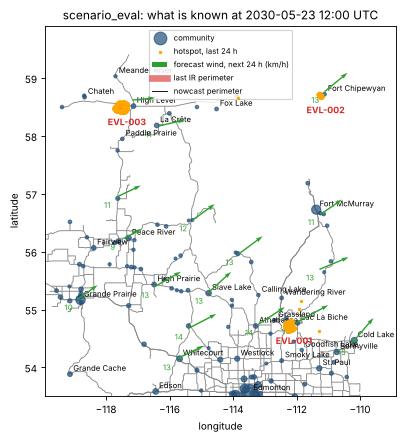

In [14]:
E = load_scenario('scenario_eval')
print(f"Decision time: {E['td']:%Y-%m-%d %H:%M} UTC; fires: {', '.join(E['meta']['fires'])}")
perims_e = nowcast_perimeters(E)
risk_e = threat_outlook(E, perims_e)
orders_e, trips_e, log_e = make_plan(E, perims_e, risk_e)

write_perimeters(perims_e, SUB / 'eval_perimeters.geojson')
risk_e[['community_id', 'p_24h', 'p_48h', 'p_72h']].to_csv(SUB / 'eval_forecast.csv', index=False)
orders_e.to_csv(SUB / 'eval_orders.csv', index=False)
trips_e.to_csv(SUB / 'eval_trips.csv', index=False)

draw_map(E, perims_e);

In [15]:
def check_submission(S, forecast, orders, trips, perims_path):
    # Quick format checks before you hand files in (the scorer does the real work).
    td = S['td']
    assert set(forecast.community_id) == set(communities.community_id)
    assert forecast[['p_24h', 'p_48h', 'p_72h']].apply(lambda s: s.between(0, 1)).all().all()
    assert (pd.to_datetime(orders.order_time, utc=True) >= td).all() and (pd.to_datetime(trips.depart_time, utc=True) >= td).all()
    assert (orders.groupby('community_id').share.sum() <= 1 + 1e-6).all()
    assert set(orders.destination_host_id) | set(trips.dropoff_host_id) <= set(hosts.host_id)
    assert set(trips.vehicle_id) <= set(fleet.vehicle_id)
    fids = {f['properties']['fire_id'] for f in json.load(open(perims_path))['features']}
    print('format OK; fires in the perimeter file:', ', '.join(sorted(fids)))


check_submission(E, risk_e, orders_e, trips_e, SUB / 'eval_perimeters.geojson')
for f in ['eval_forecast.csv', 'eval_orders.csv', 'eval_trips.csv', 'eval_perimeters.geojson']:
    print(f'  submissions/{f}  ({(SUB / f).stat().st_size:,} bytes)')
display(risk_e.merge(communities[['community_id', 'name', 'population', 'access']]).sort_values('p_72h', ascending=False)
        .head(8)[['name', 'population', 'access', 'nearest_fire', 'km_to_fire', 'p_24h', 'p_48h', 'p_72h']])
log_e

format OK; fires in the perimeter file: EVL-001, EVL-002, EVL-003
  submissions/eval_forecast.csv  (2,067 bytes)
  submissions/eval_orders.csv  (371 bytes)
  submissions/eval_trips.csv  (1,694 bytes)
  submissions/eval_perimeters.geojson  (110,652 bytes)


,name,population,access,nearest_fire,km_to_fire,p_24h,p_48h,p_72h
61,Fort Chipewyan,798,air_only,EVL-002,4.4,1.0000,1.0000,1.0000
36,Lac La Biche,2314,road,EVL-001,9.9,0.7752,0.8696,0.8732
55,Plamondon,880,road,EVL-001,7.2,0.6183,0.7682,0.7752
26,High Level,3159,road,EVL-003,10.6,0.6724,0.7524,0.7622
91,Kikino,400,road,EVL-001,21.2,0.0156,0.3774,0.4223
85,Grassland,450,road,EVL-001,21.0,0.0168,0.0966,0.1062
82,Goodfish Lake,470,road,EVL-001,41.9,0.0000,0.0193,0.0273
94,Boyle,370,road,EVL-001,30.7,0.0007,0.0186,0.0221


,community,p_24h,p_72h,people,drivers_to,riders,riders_to,vehicles,trips,last_pickup_h,note
0,Lac La Biche,0.7752,0.8732,2314,"H12 (1288), H10 (815)",211,H12,2,5,7.2,
1,High Level,0.6724,0.7622,3159,"H23 (500), H21 (599), H18 (1761)",299,H23,3,7,6.7,
2,Plamondon,0.6183,0.7752,880,H10 (740),140,H10,2,3,6.8,
3,Kikino,0.0156,0.4223,400,"H10 (25), H11 (296)",79,H10,1,2,4.4,
4,Fort Chipewyan,1.0000,1.0000,798,,798,H25,8,23,6.6,by air


To score your own practice files from a terminal:

```
python score.py forecast  --scenario scenario_practice --submission submissions/practice_forecast.csv
python score.py plan      --scenario scenario_practice --orders submissions/practice_orders.csv --trips submissions/practice_trips.csv
python score.py perimeter --scenario scenario_practice --submission submissions/practice_perimeters.geojson
```

## 8. Ideas to go further

* **Model the spread on the fuel grid.** `fuel_types_270m.tif` holds real FBP fuel types (grass burns fast, spruce crowns fast in wind, leafless aspen slowly). Read it with `rasterio`, grow the nowcast hour by hour with the forecast wind (a cellular automaton, or fastest-arrival on a grid with Dijkstra) and get arrival times instead of a heuristic.
* **Handle the wind better.** Interpolate the forecast between stations, use the wind at the fire's head rather than at the nearest station, and look for wind shifts (fronts): the flank that is quiet today can be the head tomorrow.
* **Hotspots as a time series.** Successive satellite passes show where the front was at several times: fit each fire's own rate of spread instead of one constant. Try MODIS too (1 km pixels, but the late-morning pass is the freshest view before the decision).
* **Calibrate the probabilities.** Fit the logistic curve on the practice truth (or on every 3 h truth perimeter as extra training cases), check a reliability diagram, and watch for overfitting: the eval fires are different.
* **Uncertainty-aware ordering.** Weigh the expected exposure (100 points per person) against unnecessary moves (1 point) per community; pick order times, not just yes/no; re-check the order when the forecast says a front is coming.
* **Staged and zoned evacuations.** Alert, then order; order the closest and slowest-to-empty communities first; stagger orders so they don't compete for the same exit capacity (`exit_capacity_vph`).
* **Routes and contraflow.** Avoid roads within a few km of the projected fire, prefer routes with spare capacity, and spread evacuees over several reception centres so no road or centre becomes the bottleneck.
* **Smarter fleet use.** Treat buses and aircraft as a vehicle-routing problem (e.g. OR-Tools or an integer program); helicopters can reach communities with no runway; a plane at the wrong aerodrome when it closes is a failed trip.
* **An operator dashboard.** A map and timeline a real coordinator could read in 30 seconds: who is ordered, where they are going, what happens if the front comes 6 hours early.
* **Stress-test your pipeline** on practice at other decision times: copy `scenario_practice`, change `decision_time` and `decision_hours_since_t0` in its `scenario.json` (keep it a multiple of 3 h; the scorer and `load_scenario()` both read it from there) and see whether your rules still hold up.